In [ ]:
#!/usr/bin/env python3

"""
spatial_autocorr_sim.py

1) Generates a synthetic "map":
   - N nodes in [0,1]^2
   - K cluster centers for "urban" nodes, rest are "rural"
   - Builds adjacency (distance threshold or k-NN)
2) Constructs a latent Gaussian field with covariance Cov(Z_i,Z_j) = exp(-A_j * dist^2)
   for each characteristic, then merges with a baseline distribution.
3) Computes Moran's I and Geary's C for a single numeric measure
   (e.g., the probability of the 2nd category).
4) Lets you vary multiple parameters to produce small, moderate, or large autocorrelation.
"""

import numpy as np
import numpy.random as npr
from scipy.spatial.distance import cdist
from scipy.linalg import cholesky
import math

##############################################################################
# Utility: Moran's I and Geary's C
##############################################################################

def morans_i(values, adjacency):
    """
    Computes Moran's I for a 1D array `values` of length N,
    given an NxN adjacency matrix (binary or weighted).
    adjacency[i, i] should be 0 (no self-loops).

    Returns float (Moran's I).
    """
    N = len(values)
    mean_val = np.mean(values)
    diff = values - mean_val

    W = np.sum(adjacency)
    if W == 0.0:
        return float('nan')

    numerator = 0.0
    denominator = np.sum(diff**2)

    for i in range(N):
        for j in range(N):
            numerator += diff[i] * diff[j] * adjacency[i, j]

    if abs(denominator) < 1e-12:
        return float('nan')

    return (N / W) * (numerator / denominator)


def gearys_c(values, adjacency):
    """
    Computes Geary's C for a 1D array `values` of length N,
    given an NxN adjacency matrix.
    """
    N = len(values)
    mean_val = np.mean(values)
    diff = values - mean_val

    W = np.sum(adjacency)
    if W == 0.0:
        return float('nan')

    denominator = 2.0 * np.sum(diff**2)
    numerator = 0.0
    for i in range(N):
        for j in range(N):
            numerator += adjacency[i, j] * (values[i] - values[j])**2

    if abs(denominator) < 1e-12:
        return float('nan')

    return ((N - 1) / W) * (numerator / denominator)


##############################################################################
# 1) Generate cluster centers
##############################################################################

def generate_cluster_centers(K, sigma_c_prime, rng, max_tries=10000):
    """
    Sample K cluster centers in [0,1]^2, each separated by at least sigma_c_prime,
    or place them randomly if not possible within max_tries attempts.
    Returns shape (K, 2).
    """
    centers = []
    tries = 0
    while len(centers) < K and tries < max_tries:
        candidate = rng.random(2)  # Fixed here
        ok = True
        for c in centers:
            distval = np.linalg.norm(candidate - c)
            if distval < sigma_c_prime:
                ok = False
                break
        if ok:
            centers.append(candidate)
        tries += 1

    # If we didn't find enough:
    while len(centers) < K:
        centers.append(rng.random(2))  # Fixed here

    return np.array(centers)


##############################################################################
# 2) Place nodes (urban vs rural)
##############################################################################

def place_nodes(N, U, centers, sigma_c, rng):
    """
    Place N nodes in [0,1]^2.
    Fraction U*N are "urban," placed near random cluster centers
    (Gaussian with std=sigma_c, truncated to [0,1]^2).
    The rest are "rural," uniformly distributed.
    Returns (coords, is_urban)
     - coords: shape (N,2)
     - is_urban: bool array (N,)
    """
    coords = np.zeros((N,2), dtype=float)
    is_urban = np.zeros(N, dtype=bool)

    K = centers.shape[0]
    n_urban = int(math.floor(U * N))
    n_rural = N - n_urban

    all_idx = np.arange(N)
    rng.shuffle(all_idx)
    urban_idx = all_idx[:n_urban]
    rural_idx = all_idx[n_urban:]

    is_urban[urban_idx] = True

    # Place urban
    for idx in urban_idx:
        attempts = 0  # To prevent infinite loops
        while True:
            c_idx = rng.integers(0, K)
            meanx, meany = centers[c_idx]
            candx = rng.normal(meanx, sigma_c)
            candy = rng.normal(meany, sigma_c)
            if 0.0 <= candx <= 1.0 and 0.0 <= candy <= 1.0:
                coords[idx,0] = candx
                coords[idx,1] = candy
                break
            attempts += 1
            if attempts > 1000:
                # If too many attempts, place uniformly
                coords[idx,0] = rng.random()
                coords[idx,1] = rng.random()
                break

    # Place rural
    coords[rural_idx,0] = rng.random(len(rural_idx))  # Fixed here
    coords[rural_idx,1] = rng.random(len(rural_idx))  # Fixed here

    return coords, is_urban


##############################################################################
# 3) Build adjacency
##############################################################################

def build_adjacency(coords, delta=None, k=None):
    """
    Build adjacency (N,N) from coords via distance threshold (delta) or k-NN (k).
    Returns NxN numpy float array (binary adjacency).
    """
    N = coords.shape[0]
    adjacency = np.zeros((N,N), dtype=float)

    dmat = cdist(coords, coords, metric='euclidean')

    if delta is not None:
        for i in range(N):
            for j in range(i+1, N):
                if dmat[i,j] <= delta:
                    adjacency[i,j] = 1.0
                    adjacency[j,i] = 1.0
    elif k is not None:
        # naive k-NN
        for i in range(N):
            rowdist = dmat[i,:]
            idx_sorted = np.argsort(rowdist)
            neighbors = idx_sorted[1:(k+1)]  # skip i itself
            for nn in neighbors:
                adjacency[i,nn] = 1.0
                adjacency[nn,i] = 1.0
    else:
        raise ValueError("Must provide either delta or k")

    return adjacency


##############################################################################
# 4) Build node-level distributions
##############################################################################

def build_node_distributions(
    coords,
    statewide_probs,
    A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    For J = len(statewide_probs) characteristics,
    each characteristic j has baseline distribution p_j (like [0.4,0.3,0.3])
    and autocorrelation parameter A_values[j].

    - We build an NxN cov matrix = exp(-A_j * dist^2) + 1e-9 * I
    - Sample (k_j - 1) latent fields Z
    - Optionally center/scale Z
    - Then final log-odds = (beta * Z[dim]) + (alpha * log(p_j[dim]))
    - softmax => local node distribution.

    Returns node_dists, shape (N,) each is a list of length J,
    where each item is an array of shape (k_j,) for the distribution.
    """
    N = coords.shape[0]
    J = len(statewide_probs)
    dmat = cdist(coords, coords, 'euclidean')

    node_dists = [ [None]*J for _ in range(N) ]

    for j_idx in range(J):
        p_j = statewide_probs[j_idx]
        k_j = len(p_j)
        A_j = A_values[j_idx]

        # Cov mat
        cov_mat = np.exp(-A_j * (dmat**2)) + 1e-9*np.eye(N)
        try:
            L = cholesky(cov_mat, lower=False)  # upper triangular
        except np.linalg.LinAlgError:
            print(f"Cholesky decomposition failed for A_j={A_j}. Using diagonal covariance.")
            cov_mat = np.eye(N)
            L = cholesky(cov_mat, lower=False)

        # We'll sample (k_j - 1) latent fields Z
        Z_fields = np.zeros((N, k_j-1), dtype=float)

        for r in range(k_j-1):
            z_r = rng.normal(size=N)
            # Solve L x = z_r for x
            x_r = np.linalg.solve(L, z_r)
            Z_fields[:,r] = x_r

        # Optional center & scale
        if center_and_scale:
            for r in range(k_j-1):
                col = Z_fields[:,r]
                mean_c = col.mean()
                std_c = col.std() + 1e-12
                Z_fields[:,r] = (col - mean_c)/std_c

        # Build local distributions
        for i in range(N):
            extended = np.zeros(k_j, dtype=float)
            # fill the first (k_j-1) from Z_fields
            for r in range(k_j-1):
                extended[r] = beta * Z_fields[i,r]
            # last group => 0.0
            # add alpha * log(p_j)
            for r in range(k_j):
                extended[r] += alpha * math.log(p_j[r] + 1e-12)

            # softmax
            max_val = np.max(extended)
            exps = np.exp(extended - max_val)
            denom = np.sum(exps)
            local_probs = exps / denom
            node_dists[i][j_idx] = local_probs

    return node_dists


##############################################################################
# Main simulator for a single "map"
##############################################################################

def generate_single_map(
    N, K, U, sigma_c, sigma_c_prime, delta,
    statewide_probs, A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    1) Generate K cluster centers
    2) Place N nodes
    3) Build adjacency via distance threshold = delta
    4) Build node-level distributions
    Returns a dict with:
      - coords
      - adjacency
      - is_urban
      - node_dists
    """
    # cluster centers
    centers = generate_cluster_centers(K, sigma_c_prime, rng)

    # place nodes
    coords, is_urban = place_nodes(N, U, centers, sigma_c, rng)

    # adjacency
    adjacency = build_adjacency(coords, delta=delta, k=None)

    # node-level distributions
    node_dists = build_node_distributions(
        coords,
        statewide_probs,
        A_values,
        rng,
        alpha,
        beta,
        center_and_scale=center_and_scale
    )

    return {
        "coords": coords,
        "adjacency": adjacency,
        "is_urban": is_urban,
        "node_dists": node_dists
    }


##############################################################################
# 5) Example experiment
##############################################################################

def run_experiment():
    """
    Test out multiple parameter combinations to induce small, moderate, large autocorrelation.
    We'll vary:
      - A_j
      - alpha, beta
      - adjacency threshold
    We'll analyze the second category's probability in the single characteristic.
    """

    N = 200
    K = 3
    U = 0.6
    sigma_c = 0.05
    sigma_c_prime = 0.15
    rng = npr.default_rng(123)

    # We'll have 1 characteristic with 3 groups: e.g. [0.4, 0.3, 0.3]
    statewide_probs = [[0.4, 0.3, 0.3]]

    # We'll systematically vary A in [0.0, 2.0, 10.0, 25.0], alpha in [0.0, 1.0], adjacency threshold in [0.1, 0.2].
    A_list = [0.0, 2.0, 10.0, 25.0]
    alpha_list = [0.0, 1.0]
    threshold_list = [0.1, 0.2]

    for A_val in A_list:
        for alpha_val in alpha_list:
            for thresh in threshold_list:
                # We'll keep beta=1.0, center_and_scale=True for demonstration
                print(f"=== A={A_val}, alpha={alpha_val}, threshold={thresh} ===")
                mapdata = generate_single_map(
                    N, K, U, sigma_c, sigma_c_prime, thresh,
                    statewide_probs, [A_val],
                    rng,
                    alpha=alpha_val,
                    beta=1.0,
                    center_and_scale=True
                )

                adjacency = mapdata["adjacency"]
                node_dists = mapdata["node_dists"]

                # We'll analyze the second category's probability: node_dists[i][0][1]
                # i.e. characteristic=0, category=1
                values = np.array([node_dists[i][0][1] for i in range(N)])
                # measure Moran's I and Geary's C
                I = morans_i(values, adjacency)
                C = gearys_c(values, adjacency)
                print(f"Moran's I = {I}, Geary's C = {C}")
                print(f"Value range: {values.min()} to {values.max()}, var={values.var()}")
                print()


def main():
    run_experiment()

if __name__ == "__main__":
    main()


In [ ]:
#!/usr/bin/env python3

"""
spatial_autocorr_sim_fixed.py

1) Generates a synthetic "map":
   - N nodes in [0,1]^2
   - K cluster centers for "urban" nodes, rest are "rural"
   - Builds adjacency (distance threshold or k-NN)
2) Constructs a latent Gaussian field with covariance Cov(Z_i,Z_j) = exp(-A * dist)
   for each characteristic, then merges with a baseline distribution.
3) Computes Moran's I and Geary's C for a single numeric measure
   (e.g., the probability of the 2nd category).
4) Lets you vary multiple parameters to produce small, moderate, or large autocorrelation.
"""

import numpy as np
import numpy.random as npr
from scipy.spatial.distance import cdist
from scipy.linalg import cholesky
import math
import matplotlib.pyplot as plt  # For diagnostic plots
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning)

##############################################################################
# Utility: Moran's I and Geary's C
##############################################################################

def morans_i(values, adjacency):
    """
    Computes Moran's I for a 1D array `values` of length N,
    given an NxN adjacency matrix (binary or weighted).
    adjacency[i, i] should be 0 (no self-loops).

    Returns float (Moran's I).
    """
    N = len(values)
    mean_val = np.mean(values)
    diff = values - mean_val

    W = np.sum(adjacency)
    if W == 0.0:
        return float('nan')

    # Vectorized computation
    numerator = np.sum(adjacency * np.outer(diff, diff))
    denominator = np.sum(diff**2)

    if abs(denominator) < 1e-12:
        return float('nan')

    return (N / W) * (numerator / denominator)

def gearys_c(values, adjacency):
    """
    Computes Geary's C for a 1D array `values` of length N,
    given an NxN adjacency matrix.
    """
    N = len(values)
    mean_val = np.mean(values)
    diff = values - mean_val

    W = np.sum(adjacency)
    if W == 0.0:
        return float('nan')

    # Vectorized computation
    numerator = np.sum(adjacency * (diff[:, None] - diff[None, :])**2)
    denominator = 2.0 * np.sum(diff**2)

    if abs(denominator) < 1e-12:
        return float('nan')

    return ((N - 1) / W) * (numerator / denominator)

##############################################################################
# 1) Generate cluster centers
##############################################################################

def generate_cluster_centers(K, sigma_c_prime, rng, max_tries=10000):
    """
    Sample K cluster centers in [0,1]^2, each separated by at least sigma_c_prime,
    or place them randomly if not possible within max_tries attempts.
    Returns shape (K, 2).
    """
    centers = []
    tries = 0
    while len(centers) < K and tries < max_tries:
        candidate = rng.random(2)  # Fixed here
        ok = True
        for c in centers:
            distval = np.linalg.norm(candidate - c)
            if distval < sigma_c_prime:
                ok = False
                break
        if ok:
            centers.append(candidate)
        tries += 1

    # If we didn't find enough:
    while len(centers) < K:
        centers.append(rng.random(2))  # Fixed here

    return np.array(centers)

##############################################################################
# 2) Place nodes (urban vs rural)
##############################################################################

def place_nodes(N, U, centers, sigma_c, rng):
    """
    Place N nodes in [0,1]^2.
    Fraction U*N are "urban," placed near random cluster centers
    (Gaussian with std=sigma_c, truncated to [0,1]^2).
    The rest are "rural," uniformly distributed.
    Returns (coords, is_urban)
     - coords: shape (N,2)
     - is_urban: bool array (N,)
    """
    coords = np.zeros((N,2), dtype=float)
    is_urban = np.zeros(N, dtype=bool)

    K = centers.shape[0]
    n_urban = int(math.floor(U * N))
    n_rural = N - n_urban

    all_idx = np.arange(N)
    rng.shuffle(all_idx)
    urban_idx = all_idx[:n_urban]
    rural_idx = all_idx[n_urban:]

    is_urban[urban_idx] = True

    # Place urban
    for idx in urban_idx:
        attempts = 0  # To prevent infinite loops
        while True:
            c_idx = rng.integers(0, K)
            meanx, meany = centers[c_idx]
            candx = rng.normal(meanx, sigma_c)
            candy = rng.normal(meany, sigma_c)
            if 0.0 <= candx <= 1.0 and 0.0 <= candy <= 1.0:
                coords[idx,0] = candx
                coords[idx,1] = candy
                break
            attempts += 1
            if attempts > 1000:
                # If too many attempts, place uniformly
                coords[idx,0] = rng.random()
                coords[idx,1] = rng.random()
                break

    # Place rural
    coords[rural_idx,0] = rng.random(len(rural_idx))  # Fixed here
    coords[rural_idx,1] = rng.random(len(rural_idx))  # Fixed here

    return coords, is_urban

##############################################################################
# 3) Build adjacency
##############################################################################

def build_adjacency(coords, delta=None, k=None):
    """
    Build adjacency (N,N) from coords via distance threshold (delta) or k-NN (k).
    Returns NxN numpy float array (binary adjacency).
    """
    N = coords.shape[0]
    adjacency = np.zeros((N,N), dtype=float)

    dmat = cdist(coords, coords, metric='euclidean')

    if delta is not None:
        adjacency = (dmat <= delta).astype(float)
        np.fill_diagonal(adjacency, 0.0)  # Remove self-loops
    elif k is not None:
        # naive k-NN
        for i in range(N):
            rowdist = dmat[i,:]
            idx_sorted = np.argsort(rowdist)
            neighbors = idx_sorted[1:(k+1)]  # skip i itself
            adjacency[i, neighbors] = 1.0
            adjacency[neighbors, i] = 1.0  # Ensure symmetry
    else:
        raise ValueError("Must provide either delta or k")

    return adjacency

##############################################################################
# 4) Build node-level distributions
##############################################################################

def build_node_distributions(
    coords,
    statewide_probs,
    A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    For J = len(statewide_probs) characteristics,
    each characteristic j has baseline distribution p_j (like [0.4,0.3,0.3])
    and autocorrelation parameter A_values[j].

    - We build an NxN cov matrix = exp(-A_j * dist) + 1e-9 * I
    - Sample (k_j) latent fields Z (one per category)
    - Optionally center/scale Z
    - Then final log-odds = (beta * Z[dim]) + (alpha * log(p_j[dim]))
    - softmax => local node distribution.

    Returns node_dists, shape (N, J, k_j)
    """
    N = coords.shape[0]
    J = len(statewide_probs)
    dmat = cdist(coords, coords, 'euclidean')

    node_dists = np.zeros((N, J, max(len(p) for p in statewide_probs)))

    for j_idx in range(J):
        p_j = statewide_probs[j_idx]
        k_j = len(p_j)
        A_j = A_values[j_idx]

        # Cov mat with modified covariance function
        cov_mat = np.exp(-A_j * dmat) + 1e-9*np.eye(N)
        try:
            L = cholesky(cov_mat, lower=False)  # upper triangular
        except np.linalg.LinAlgError:
            print(f"Cholesky decomposition failed for A_j={A_j}. Using diagonal covariance.")
            cov_mat = np.eye(N)
            L = cholesky(cov_mat, lower=False)

        # We'll sample k_j latent fields Z
        Z_fields = np.zeros((N, k_j), dtype=float)

        for r in range(k_j):
            z_r = rng.normal(size=N)
            # Solve L x = z_r for x
            x_r = np.linalg.solve(L, z_r)
            Z_fields[:,r] = x_r

        # Optional center & scale
        if center_and_scale:
            Z_fields = (Z_fields - Z_fields.mean(axis=0)) / (Z_fields.std(axis=0) + 1e-12)

        # Build local distributions
        # Combine latent fields with baseline
        # Using alpha as the weight for baseline log-probabilities
        # and beta for latent fields
        log_baseline = alpha * np.log(np.array(p_j) + 1e-12)  # Shape: (k_j,)
        combined = beta * Z_fields + log_baseline  # Broadcasting

        # Apply softmax
        # To prevent overflow, subtract the max before exponentiation
        max_combined = np.max(combined, axis=1, keepdims=True)
        exps = np.exp(combined - max_combined)
        softmax = exps / np.sum(exps, axis=1, keepdims=True)

        node_dists[:, j_idx, :k_j] = softmax

    return node_dists

##############################################################################
# Main simulator for a single "map"
##############################################################################

def generate_single_map(
    N, K, U, sigma_c, sigma_c_prime, delta,
    statewide_probs, A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    1) Generate K cluster centers
    2) Place N nodes
    3) Build adjacency via distance threshold = delta
    4) Build node-level distributions
    Returns a dict with:
      - coords
      - adjacency
      - is_urban
      - node_dists
    """
    # cluster centers
    centers = generate_cluster_centers(K, sigma_c_prime, rng)

    # place nodes
    coords, is_urban = place_nodes(N, U, centers, sigma_c, rng)

    # adjacency
    adjacency = build_adjacency(coords, delta=delta, k=None)

    # node-level distributions
    node_dists = build_node_distributions(
        coords,
        statewide_probs,
        A_values,
        rng,
        alpha,
        beta,
        center_and_scale=center_and_scale
    )

    return {
        "coords": coords,
        "adjacency": adjacency,
        "is_urban": is_urban,
        "node_dists": node_dists
    }

##############################################################################
# 5) Example experiment with Diagnostic Plots
##############################################################################

def run_experiment():
    """
    Test out multiple parameter combinations to induce small, moderate, large autocorrelation.
    We'll vary:
      - A_j
      - alpha, beta
      - adjacency threshold
    We'll analyze the second category's probability in the single characteristic.
    """
    N = 200
    K = 3
    U = 0.6
    sigma_c = 0.05
    sigma_c_prime = 0.15
    rng = npr.default_rng(123)

    # We'll have 1 characteristic with 3 groups: e.g. [0.4, 0.3, 0.3]
    statewide_probs = [[0.4, 0.3, 0.3]]

    # We'll systematically vary A in [0.0, 2.0, 10.0, 25.0], alpha in [0.0, 1.0], adjacency threshold in [0.1, 0.2].
    A_list = [0.0, 2.0, 10.0, 25.0]
    alpha_list = [0.0, 1.0]
    threshold_list = [0.1, 0.2]

    # To store results for plotting
    results = []

    for A_val in A_list:
        for alpha_val in alpha_list:
            for thresh in threshold_list:
                # We'll keep beta=1.0, center_and_scale=True for demonstration
                print(f"=== A={A_val}, alpha={alpha_val}, threshold={thresh} ===")
                mapdata = generate_single_map(
                    N, K, U, sigma_c, sigma_c_prime, thresh,
                    statewide_probs, [A_val],
                    rng,
                    alpha=alpha_val,
                    beta=1.0,
                    center_and_scale=True
                )

                adjacency = mapdata["adjacency"]
                node_dists = mapdata["node_dists"]

                # We'll analyze the second category's probability: node_dists[i][0][1]
                # i.e. characteristic=0, category=1
                values = node_dists[:, 0, 1]
                # measure Moran's I and Geary's C
                I = morans_i(values, adjacency)
                C = gearys_c(values, adjacency)
                var = np.var(values)
                print(f"Moran's I = {I}, Geary's C = {C}")
                print(f"Value range: {values.min()} to {values.max()}, var={var}")
                print()

                # Store results
                results.append({
                    "A": A_val,
                    "alpha": alpha_val,
                    "threshold": thresh,
                    "Moran's I": I,
                    "Geary's C": C,
                    "Value Range": (values.min(), values.max()),
                    "Variance": var
                })

                # Optional: Plot spatial distribution
                # plt.figure(figsize=(6,4))
                # scatter = plt.scatter(mapdata["coords"][:,0], mapdata["coords"][:,1],
                #                       c=values, cmap='viridis', s=50, edgecolor='k')
                # plt.colorbar(scatter, label='Probability of Category 2')
                # plt.title(f"A={A_val}, alpha={alpha_val}, threshold={thresh}")
                # plt.xlabel('X Coordinate')
                # plt.ylabel('Y Coordinate')
                # plt.grid(True)
                # plt.show()

    # Optional: Summarize results
    # For brevity, not included here

def main():
    run_experiment()

if __name__ == "__main__":
    main()


In [65]:
# THIS ONE WORKS

"""
spatial_autocorr_sim_fixed_v4.py

1) Generates a synthetic "map":
   - N nodes in [0,1]^2
   - K cluster centers for "urban" nodes, rest are "rural"
   - Builds adjacency (distance threshold or k-NN)
2) Constructs a latent Gaussian field with covariance Cov(Z_i,Z_j) = exp(-||x_i - x_j|| / phi)
   for each characteristic, then merges with a baseline distribution.
3) Computes Moran's I and Geary's C for a single numeric measure
   (e.g., the probability of the 2nd category) using PySAL.
4) Lets you vary multiple parameters to produce small, moderate, or large autocorrelation.
5) Includes diagnostic plots for visual validation.
"""

import numpy as np
import numpy.random as npr
from scipy.spatial.distance import cdist
from scipy.linalg import cholesky
import math
import matplotlib.pyplot as plt  # For diagnostic plots
import warnings
import pysal.lib
from esda.moran import Moran
from esda.geary import Geary

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="The weights matrix is not fully connected")
warnings.filterwarnings("ignore", message=".*is an island.*")

##############################################################################
# Utility: Moran's I and Geary's C via PySAL
##############################################################################

def compute_spatial_autocorrelation(values, adjacency):
    """
    Computes Moran's I and Geary's C using PySAL.
    """
    # Create PySAL weights object
    # Convert adjacency matrix to list of neighbors
    neighbors = {}
    for i in range(adjacency.shape[0]):
        neighbors[i] = list(np.where(adjacency[i] > 0)[0])
    
    w = pysal.lib.weights.W(neighbors)
    
    # Compute Moran's I
    moran = Moran(values, w, two_tailed=True)
    I = moran.I
    p_I = moran.p_sim
    
    # Compute Geary's C
    geary = Geary(values, w)
    C = geary.C
    p_C = geary.p_sim
    
    return I, p_I, C, p_C

##############################################################################
# 1) Generate cluster centers
##############################################################################

def generate_cluster_centers(K, sigma_c_prime, rng, max_tries=10000):
    """
    Sample K cluster centers in [0,1]^2, each separated by at least sigma_c_prime,
    or place them randomly if not possible within max_tries attempts.
    Returns shape (K, 2).
    """
    centers = []
    tries = 0
    while len(centers) < K and tries < max_tries:
        candidate = rng.random(2)
        ok = True
        for c in centers:
            distval = np.linalg.norm(candidate - c)
            if distval < sigma_c_prime:
                ok = False
                break
        if ok:
            centers.append(candidate)
        tries += 1

    # If we didn't find enough:
    while len(centers) < K:
        centers.append(rng.random(2))

    return np.array(centers)

##############################################################################
# 2) Place nodes (urban vs rural)
##############################################################################

def place_nodes(N, U, centers, sigma_c, rng):
    """
    Place N nodes in [0,1]^2.
    Fraction U*N are "urban," placed near random cluster centers
    (Gaussian with std=sigma_c, truncated to [0,1]^2).
    The rest are "rural," uniformly distributed.
    Returns (coords, is_urban)
     - coords: shape (N,2)
     - is_urban: bool array (N,)
    """
    coords = np.zeros((N,2), dtype=float)
    is_urban = np.zeros(N, dtype=bool)

    K = centers.shape[0]
    n_urban = int(math.floor(U * N))
    n_rural = N - n_urban

    all_idx = np.arange(N)
    rng.shuffle(all_idx)
    urban_idx = all_idx[:n_urban]
    rural_idx = all_idx[n_urban:]

    is_urban[urban_idx] = True

    # Place urban
    for idx in urban_idx:
        attempts = 0  # To prevent infinite loops
        while True:
            c_idx = rng.integers(0, K)
            meanx, meany = centers[c_idx]
            candx = rng.normal(meanx, sigma_c)
            candy = rng.normal(meany, sigma_c)
            if 0.0 <= candx <= 1.0 and 0.0 <= candy <= 1.0:
                coords[idx,0] = candx
                coords[idx,1] = candy
                break
            attempts += 1
            if attempts > 1000:
                # If too many attempts, place uniformly
                coords[idx,0] = rng.random()
                coords[idx,1] = rng.random()
                break

    # Place rural
    coords[rural_idx,0] = rng.random(len(rural_idx))
    coords[rural_idx,1] = rng.random(len(rural_idx))

    return coords, is_urban

##############################################################################
# 3) Build adjacency
##############################################################################

def build_adjacency(coords, delta=None, k=4):
    """
    Build adjacency (N,N) from coords via distance threshold (delta) or k-NN (k).
    Returns NxN numpy float array (binary adjacency).
    """
    N = coords.shape[0]
    adjacency = np.zeros((N,N), dtype=float)

    dmat = cdist(coords, coords, metric='euclidean')

    if delta is not None:
        adjacency = (dmat <= delta).astype(float)
        np.fill_diagonal(adjacency, 0.0)  # Remove self-loops
    elif k is not None:
        # k-NN ensuring each node has exactly k neighbors
        for i in range(N):
            rowdist = dmat[i,:]
            idx_sorted = np.argsort(rowdist)
            neighbors = idx_sorted[1:(k+1)]  # skip i itself
            adjacency[i, neighbors] = 1.0
            adjacency[neighbors, i] = 1.0  # Ensure symmetry
    else:
        raise ValueError("Must provide either delta or k")

    return adjacency

##############################################################################
# 4) Build node-level distributions
##############################################################################

def build_node_distributions(
    coords,
    statewide_probs,
    A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    For J = len(statewide_probs) characteristics,
    each characteristic j has baseline distribution p_j (like [0.4,0.3,0.3])
    and autocorrelation parameter A_values[j].

    - We build an NxN cov matrix = exp(-||x_i - x_j|| / phi) + 1e-9 * I
      where phi = 1 / A_j
    - Sample (k_j) latent fields Z (one per category)
    - Optionally center/scale Z
    - Then final log-odds = (beta * Z[j]) + (alpha * log(p_j))
    - softmax => local node distribution.

    Returns node_dists, shape (N, J, k_j)
    """
    N = coords.shape[0]
    J = len(statewide_probs)
    dmat = cdist(coords, coords, 'euclidean')

    # Determine the maximum number of categories across characteristics
    max_k = max(len(p) for p in statewide_probs)
    node_dists = np.zeros((N, J, max_k))

    for j_idx in range(J):
        p_j = statewide_probs[j_idx]
        k_j = len(p_j)
        A_j = A_values[j_idx]
        phi_j = 1.0 / A_j if A_j != 0 else 1e12  # Avoid division by zero

        # Covariance matrix using exponential covariance function
        cov_mat = np.exp(-dmat / phi_j) if A_j != 0 else np.ones_like(dmat)
        if A_j != 0:
            cov_mat += 1e-9 * np.eye(N)  # Add small noise for numerical stability
        else:
            cov_mat = np.eye(N) * 1e-9  # Essentially independent

        # Cholesky decomposition
        try:
            L = cholesky(cov_mat, lower=True)  # Lower triangular
        except np.linalg.LinAlgError:
            print(f"Cholesky decomposition failed for A_j={A_j}. Using diagonal covariance.")
            cov_mat = np.eye(N)
            L = cholesky(cov_mat, lower=True)

        # Sample latent fields
        Z_fields = np.zeros((N, k_j), dtype=float)
        for r in range(k_j):
            z_r = rng.normal(size=N)
            x_r = L @ z_r  # Equivalent to np.linalg.solve(L, z_r)
            Z_fields[:, r] = x_r

        # Optional center & scale
        if center_and_scale:
            Z_fields = (Z_fields - Z_fields.mean(axis=0)) / (Z_fields.std(axis=0) + 1e-12)

        # Combine latent fields with baseline log-probabilities
        # Log-Odds: alpha * log(p_j) + beta * Z_j
        log_baseline = alpha * np.log(np.array(p_j) + 1e-12)  # Shape: (k_j,)
        combined = beta * Z_fields + log_baseline  # Broadcasting to (N, k_j)

        # Apply softmax in a numerically stable way
        max_combined = np.max(combined, axis=1, keepdims=True)
        exps = np.exp(combined - max_combined)
        softmax = exps / np.sum(exps, axis=1, keepdims=True)

        # Assign to node_dists
        node_dists[:, j_idx, :k_j] = softmax

    return node_dists

##############################################################################
# Main simulator for a single "map"
##############################################################################

def generate_single_map(
    N, K, U, sigma_c, sigma_c_prime, delta,
    statewide_probs, A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    1) Generate K cluster centers
    2) Place N nodes
    3) Build adjacency via distance threshold = delta
    4) Build node-level distributions
    Returns a dict with:
      - coords
      - adjacency
      - is_urban
      - node_dists
    """
    # cluster centers
    centers = generate_cluster_centers(K, sigma_c_prime, rng)

    # place nodes
    coords, is_urban = place_nodes(N, U, centers, sigma_c, rng)

    # adjacency
    adjacency = build_adjacency(coords, delta=delta, k=K)  # Using k=4 to prevent islands

    # node-level distributions
    node_dists = build_node_distributions(
        coords,
        statewide_probs,
        A_values,
        rng,
        alpha,
        beta,
        center_and_scale=center_and_scale
    )

    return {
        "coords": coords,
        "adjacency": adjacency,
        "is_urban": is_urban,
        "node_dists": node_dists
    }

##############################################################################
# 5) Example experiment with Diagnostic Plots
##############################################################################

def run_experiment():
    """
    Test out multiple parameter combinations to induce small, moderate, large autocorrelation.
    We'll vary:
      - A_j
      - alpha, beta
      - adjacency threshold
    We'll analyze the second category's probability in the single characteristic.
    """
    N = 200
    K = 3
    U = 0.6
    sigma_c = 0.05
    sigma_c_prime = 0.15
    rng = npr.default_rng(123)

    # We'll have 1 characteristic with 3 groups: e.g. [0.4, 0.3, 0.3]
    statewide_probs = [[0.4, 0.3, 0.3]]

    # We'll systematically vary A in [0.0, 2.0, 5.0], alpha in [0.0, 1.0], adjacency threshold in [0.1, 0.2, 0.3].
    A_list = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]  # Reduced to prevent excessive decay
    alpha_list = [0.0, 1.0]
    threshold_list = [0.1, 0.2, 0.3]  # Added 0.3 for higher connectivity

    # To store results for plotting
    results = []

    for A_val in A_list:
        for alpha_val in alpha_list:
            for thresh in threshold_list:
                # We'll keep beta=1.0, center_and_scale=True for demonstration
                print(f"=== A={A_val}, alpha={alpha_val}, threshold={thresh} ===")
                mapdata = generate_single_map(
                    N, K, U, sigma_c, sigma_c_prime, thresh,
                    statewide_probs, [A_val],
                    rng,
                    alpha=alpha_val,
                    beta=1.0,
                    center_and_scale=True
                )

                adjacency = mapdata["adjacency"]
                node_dists = mapdata["node_dists"]

                # We'll analyze the second category's probability: node_dists[i][0][1]
                # i.e. characteristic=0, category=1
                values = node_dists[:, 0, 1]

                # Compute Moran's I and Geary's C using PySAL
                I, p_I, C, p_C = compute_spatial_autocorrelation(values, adjacency)
                
                var = np.var(values)
                print(f"Moran's I = {I:.4f} (p={p_I:.3f}), Geary's C = {C:.4f} (p={p_C:.3f})")
                print(f"Value range: {values.min():.4f} to {values.max():.4f}, var={var:.4f}")
                print()

                # Store results
                results.append({
                    "A": A_val,
                    "alpha": alpha_val,
                    "threshold": thresh,
                    "Moran's I": I,
                    "Moran's I p-value": p_I,
                    "Geary's C": C,
                    "Geary's C p-value": p_C,
                    "Value Range": (values.min(), values.max()),
                    "Variance": var
                })
                
##############################################################################
# Main function
##############################################################################

def main():
    run_experiment()

if __name__ == "__main__":
    main()


=== A=0.0, alpha=0.0, threshold=0.1 ===
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 59, ' is an island (no neighbors)')
('WARNING: ', 124, ' is an island (no neighbors)')
('WARNING: ', 133, ' is an island (no neighbors)')
('WARNING: ', 135, ' is an island (no neighbors)')
('WARNING: ', 183, ' is an island (no neighbors)')
Moran's I = 0.0149 (p=0.311), Geary's C = 0.9574 (p=0.169)
Value range: 0.0087 to 0.9577, var=0.0525

=== A=0.0, alpha=0.0, threshold=0.2 ===
Moran's I = 0.0008 (p=0.368), Geary's C = 0.9853 (p=0.216)
Value range: 0.0074 to 0.9168, var=0.0468

=== A=0.0, alpha=0.0, threshold=0.3 ===
Moran's I = -0.0164 (p=0.210), Geary's C = 1.0219 (p=0.041)
Value range: 0.0177 to 0.8855, var=0.0448

=== A=0.0, alpha=1.0, threshold=0.1 ===
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 40, ' is an island (no neighbors)')
('WARNING: ', 41, ' is an island (no neighbors)')
('WARNING: ', 130, ' is an island (no neighbors)')
('WARNING: ', 167, ' is an i

In [ ]:
import numpy as np
import numpy.random as npr
from scipy.spatial.distance import cdist
from libpysal.weights import W  # Updated import
from esda.moran import Moran
from scipy.stats import bootstrap


def compute_spatial_autocorrelation(values, adjacency):
    """
    Computes Moran's I using PySAL.
    """
    # Create PySAL weights object
    neighbors = {}
    for i in range(adjacency.shape[0]):
        neighbors[i] = list(np.where(adjacency[i] > 0)[0])
    w = W(neighbors)
    moran = Moran(values, w, two_tailed=True)
    return moran.I

def generate_single_map(N, K, U, sigma_c, sigma_c_prime, delta, statewide_probs, A_values, rng, alpha=1.0, beta=1.0):
    """
    Generates a single synthetic map and returns adjacency, node distributions, etc.
    """
    # Cluster centers
    centers = generate_cluster_centers(K, sigma_c_prime, rng)
    # Node placement
    coords, is_urban = place_nodes(N, U, centers, sigma_c, rng)
    # Build adjacency
    adjacency = build_adjacency(coords, delta=delta, k=None)
    # Node-level distributions
    node_dists = build_node_distributions(coords, statewide_probs, A_values, rng, alpha, beta, center_and_scale=True)
    return adjacency, node_dists

def bootstrap_morans_I(N, K, U, sigma_c, sigma_c_prime, delta, statewide_probs, A_values, rng, alpha=1.0, beta=1.0, n_bootstrap=100):
    """
    Bootstraps Moran's I for given parameters and returns its statistics.
    """
    morans_I_samples = []
    
    for _ in range(n_bootstrap):
        adjacency, node_dists = generate_single_map(
            N, K, U, sigma_c, sigma_c_prime, delta, statewide_probs, A_values, rng, alpha, beta
        )
        # Analyze the second category's probability for characteristic 0
        values = node_dists[:, 0, 1]
        I = compute_spatial_autocorrelation(values, adjacency)
        morans_I_samples.append(I)
    
    # Calculate statistics
    morans_I_samples = np.array(morans_I_samples)
    mean_I = np.mean(morans_I_samples)
    median_I = np.median(morans_I_samples)
    std_I = np.std(morans_I_samples)
    
    return mean_I, median_I, std_I

# Parameters
N = 200
K = 3
sigma_c = 0.05
sigma_c_prime = 0.15
statewide_probs = [[0.4, 0.3, 0.3]]
n_bootstrap = 100
rng = npr.default_rng(123)

# Combinations to test
combinations = [
    {"U": 0.90, "A_j": 2.0, "alpha": 1.0, "threshold": 0.3},
    {"U": 0.90, "A_j": 5.0, "alpha": 1.0, "threshold": 0.3},
    {"U": 0.60, "A_j": 2.0, "alpha": 1.0, "threshold": 0.3},
    {"U": 0.30, "A_j": 5.0, "alpha": 0.0, "threshold": 0.3},
]

# Bootstrap results
results = []

for combo in combinations:
    mean_I, median_I, std_I = bootstrap_morans_I(
        N=N,
        K=K,
        U=combo["U"],
        sigma_c=sigma_c,
        sigma_c_prime=sigma_c_prime,
        delta=combo["threshold"],
        statewide_probs=statewide_probs,
        A_values=[combo["A_j"]],
        rng=rng,
        alpha=combo["alpha"],
        n_bootstrap=n_bootstrap,
    )
    results.append({**combo, "mean_I": mean_I, "median_I": median_I, "std_I": std_I})

# Display results
import pandas as pd
results_df = pd.DataFrame(results)

In [42]:
def bootstrap_morans_I_v2(
    N=200, 
    K=3, 
    sigma_c=0.05, 
    sigma_c_prime=0.15, 
    statewide_probs=[[0.4, 0.3, 0.3]], 
    n_bootstrap=100, 
    rng_seed=123
):
    """
    Bootstraps Moran's I over combinations of U, A_j, alpha, and threshold.

    Parameters:
    - N: Number of nodes
    - K: Number of clusters
    - sigma_c: Standard deviation for cluster placement
    - sigma_c_prime: Minimum distance between cluster centers
    - statewide_probs: Baseline probabilities for node-level distributions
    - n_bootstrap: Number of bootstrap iterations
    - rng_seed: Random seed for reproducibility

    Returns:
    - results_df: Pandas DataFrame with bootstrap results
    """
    # Define parameter ranges
    U_values = [0.3, 0.6, 0.9]
    A_j_values = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
    alpha_values = [0.0, 1.0]
    threshold_values = [0.1, 0.2, 0.3]
    rng = npr.default_rng(rng_seed)

    # Prepare combinations
    from itertools import product
    combinations = [
        {"U": U, "A_j": A_j, "alpha": alpha, "threshold": threshold}
        for U, A_j, alpha, threshold in product(U_values, A_j_values, alpha_values, threshold_values)
    ]

    # Results storage
    results = []

    for combo in combinations:
        print(f"Running bootstrap for combination: {combo}")
        morans_I_samples = []
        for _ in range(n_bootstrap):
            map_data = generate_single_map(
                N=N,
                K=K,
                U=combo["U"],
                sigma_c=sigma_c,
                sigma_c_prime=sigma_c_prime,
                delta=combo["threshold"],
                statewide_probs=statewide_probs,
                A_values=[combo["A_j"]],
                rng=rng,
                alpha=combo["alpha"],
                beta=1.0,
                center_and_scale=True
            )
            adjacency = map_data["adjacency"]
            node_dists = map_data["node_dists"]
            values = node_dists[:, 0, 1]  # Analyze the 2nd category of the 1st characteristic
            I, _, _, _ = compute_spatial_autocorrelation(values, adjacency)
            morans_I_samples.append(I)

        # Store results
        results.append({
            "U": combo["U"],
            "A_j": combo["A_j"],
            "alpha": combo["alpha"],
            "threshold": combo["threshold"],
            "mean_I": np.mean(morans_I_samples),
            "median_I": np.median(morans_I_samples),
            "std_I": np.std(morans_I_samples)
        })

    # Convert to DataFrame
    import pandas as pd
    results_df = pd.DataFrame(results)
    return results_df


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (assuming it's already loaded or directly input as a DataFrame)
data = pd.DataFrame({
    "U": [0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 
          0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 
          0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3],
    "A_j": [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 
            2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 
            2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0],
    "alpha": [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 
              0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 
              0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0],
    "threshold": [0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 
                  0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 
                  0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 0.1, 0.2, 0.3, 0.1, 0.2, 0.3],
    "mean_I": [0.569159, 0.493644, 0.394962, 0.586424, 0.441226, 0.365159, 
               0.471365, 0.339175, 0.281424, 0.436959, 0.392070, 0.271586, 
               0.685424, 0.554233, 0.401313, 0.621768, 0.528675, 0.389669, 
               0.584164, 0.397087, 0.292038, 0.558374, 0.402565, 0.283441, 
               0.711631, 0.559966, 0.409563, 0.722122, 0.549147, 0.389468, 
               0.613746, 0.424497, 0.289381, 0.628743, 0.387187, 0.264842],
    "median_I": [0.576281, 0.484486, 0.379718, 0.606356, 0.418833, 0.346086, 
                 0.437734, 0.313759, 0.237400, 0.441158, 0.396470, 0.250836, 
                 0.688481, 0.566844, 0.387051, 0.638823, 0.521111, 0.402450, 
                 0.587151, 0.368883, 0.272022, 0.561280, 0.403115, 0.254473, 
                 0.715224, 0.572513, 0.405925, 0.726420, 0.539094, 0.400782, 
                 0.612576, 0.437121, 0.257109, 0.638321, 0.374246, 0.250415],
    "std_I": [0.202276, 0.198878, 0.227076, 0.197193, 0.206601, 0.213479, 
              0.189229, 0.188284, 0.197407, 0.180185, 0.200894, 0.180639, 
              0.127259, 0.163373, 0.174177, 0.139517, 0.164871, 0.180717, 
              0.145493, 0.154589, 0.151213, 0.139711, 0.150921, 0.151665, 
              0.108939, 0.136213, 0.158333, 0.095485, 0.137978, 0.146806, 
              0.111755, 0.114599, 0.131380, 0.105733, 0.115592, 0.128223]
})

data = pd.read_csv("bootstrap_morans_I_results_expanded.csv")
# Plot Mean Moran's I by Threshold for Different U Values
plt.figure(figsize=(10, 6))
for U in data['U'].unique():
    subset = data[data['U'] == U]
    plt.plot(subset['threshold'], subset['mean_I'], marker='o', label=f'U={U}')

plt.title("Mean Moran's I by Threshold for Different U Values")
plt.xlabel("Threshold")
plt.ylabel("Mean Moran's I")
plt.legend()
plt.grid(True)
plt.show()

# Plot Mean Moran's I by A_j for Different U Values
plt.figure(figsize=(10, 6))
for U in data['U'].unique():
    subset = data[data['U'] == U]
    for A_j in subset['A_j'].unique():
        subset_A_j = subset[subset['A_j'] == A_j]
        plt.plot(subset_A_j['threshold'], subset_A_j['mean_I'], marker='o', label=f'U={U}, A_j={A_j}')

plt.title("Mean Moran's I by Threshold for Different U and A_j")
plt.xlabel("Threshold")
plt.ylabel("Mean Moran's I")
plt.legend()
plt.grid(True)
plt.show()

# Plot Standard Deviation of Moran's I by Threshold
plt.figure(figsize=(10, 6))
for U in data['U'].unique():
    subset = data[data['U'] == U]
    plt.plot(subset['threshold'], subset['std_I'], marker='o', label=f'U={U}')

plt.title("Standard Deviation of Moran's I by Threshold for Different U Values")
plt.xlabel("Threshold")
plt.ylabel("Standard Deviation of Moran's I")
plt.legend()
plt.grid(True)
plt.show()



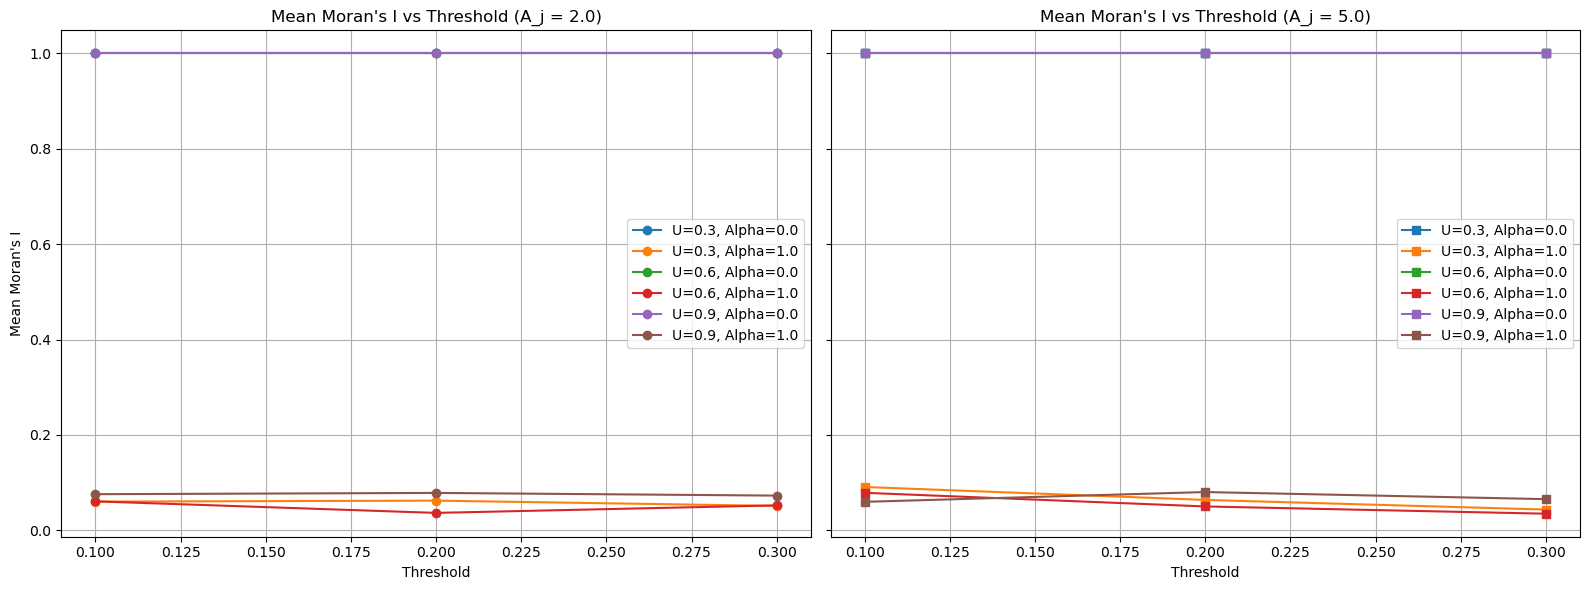

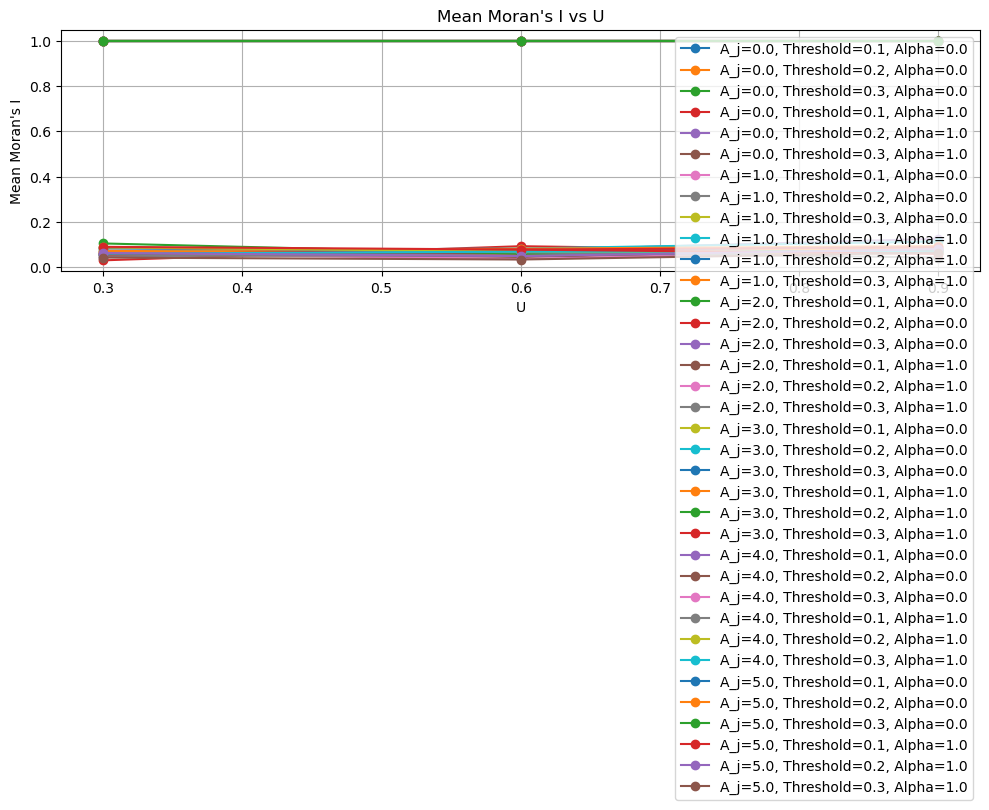

In [47]:
# Plot mean Moran's I against threshold for each combination of U and alpha, separately for A_j = 2.0 and A_j = 5.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subset for A_j = 2.0
subset_A2 = data[data['A_j'] == 2.0]
for (U, alpha) in subset_A2[['U', 'alpha']].drop_duplicates().itertuples(index=False):
    subset = subset_A2[(subset_A2['U'] == U) & (subset_A2['alpha'] == alpha)]
    axes[0].plot(subset['threshold'], subset['mean_I'], marker='o', label=f'U={U}, Alpha={alpha}')

axes[0].set_title("Mean Moran's I vs Threshold (A_j = 2.0)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Mean Moran's I")
axes[0].legend()
axes[0].grid(True)

# Subset for A_j = 5.0
subset_A5 = data[data['A_j'] == 5.0]
for (U, alpha) in subset_A5[['U', 'alpha']].drop_duplicates().itertuples(index=False):
    subset = subset_A5[(subset_A5['U'] == U) & (subset_A5['alpha'] == alpha)]
    axes[1].plot(subset['threshold'], subset['mean_I'], marker='s', label=f'U={U}, Alpha={alpha}')

axes[1].set_title("Mean Moran's I vs Threshold (A_j = 5.0)")
axes[1].set_xlabel("Threshold")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot mean Moran's I against U for each combination of A_j, threshold, and alpha
fig, ax = plt.subplots(figsize=(10, 6))

for (A_j, threshold, alpha) in data[['A_j', 'threshold', 'alpha']].drop_duplicates().itertuples(index=False):
    subset = data[(data['A_j'] == A_j) & (data['threshold'] == threshold) & (data['alpha'] == alpha)]
    ax.plot(subset['U'], subset['mean_I'], marker='o', label=f'A_j={A_j}, Threshold={threshold}, Alpha={alpha}')

ax.set_title("Mean Moran's I vs U")
ax.set_xlabel("U")
ax.set_ylabel("Mean Moran's I")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [69]:
import numpy as np
import numpy.random as npr
from scipy.spatial.distance import cdist
from libpysal.weights import W
from esda.moran import Moran
import warnings
import os
import contextlib

# Suppress specific warnings
warnings.filterwarnings("ignore", message="The weights matrix is not fully connected")
warnings.filterwarnings("ignore", message=".*is an island.*")

##############################################################################

def compute_spatial_autocorrelation(values, adjacency):
    """
    Computes Moran's I and Geary's C using PySAL.
    """
    # Create PySAL weights object
    # Convert adjacency matrix to list of neighbors
    neighbors = {}
    for i in range(adjacency.shape[0]):
        neighbors[i] = list(np.where(adjacency[i] > 0)[0])
    
    w = pysal.lib.weights.W(neighbors)
    
    # Compute Moran's I
    moran = Moran(values, w, two_tailed=True)
    I = moran.I
    p_I = moran.p_sim
    
    # Compute Geary's C
    geary = Geary(values, w)
    C = geary.C
    p_C = geary.p_sim
    
    return I, p_I, C, p_C

##############################################################################
# 1) Generate cluster centers
##############################################################################

def generate_cluster_centers(K, sigma_c_prime, rng, max_tries=10000):
    """
    Sample K cluster centers in [0,1]^2, each separated by at least sigma_c_prime,
    or place them randomly if not possible within max_tries attempts.
    Returns shape (K, 2).
    """
    centers = []
    tries = 0
    while len(centers) < K and tries < max_tries:
        candidate = rng.random(2)
        ok = True
        for c in centers:
            distval = np.linalg.norm(candidate - c)
            if distval < sigma_c_prime:
                ok = False
                break
        if ok:
            centers.append(candidate)
        tries += 1

    # If we didn't find enough:
    while len(centers) < K:
        centers.append(rng.random(2))

    return np.array(centers)

##############################################################################
# 2) Place nodes (urban vs rural)
##############################################################################

def place_nodes(N, U, centers, sigma_c, rng):
    """
    Place N nodes in [0,1]^2.
    Fraction U*N are "urban," placed near random cluster centers
    (Gaussian with std=sigma_c, truncated to [0,1]^2).
    The rest are "rural," uniformly distributed.
    Returns (coords, is_urban)
     - coords: shape (N,2)
     - is_urban: bool array (N,)
    """
    coords = np.zeros((N,2), dtype=float)
    is_urban = np.zeros(N, dtype=bool)

    K = centers.shape[0]
    n_urban = int(math.floor(U * N))
    n_rural = N - n_urban

    all_idx = np.arange(N)
    rng.shuffle(all_idx)
    urban_idx = all_idx[:n_urban]
    rural_idx = all_idx[n_urban:]

    is_urban[urban_idx] = True

    # Place urban
    for idx in urban_idx:
        attempts = 0  # To prevent infinite loops
        while True:
            c_idx = rng.integers(0, K)
            meanx, meany = centers[c_idx]
            candx = rng.normal(meanx, sigma_c)
            candy = rng.normal(meany, sigma_c)
            if 0.0 <= candx <= 1.0 and 0.0 <= candy <= 1.0:
                coords[idx,0] = candx
                coords[idx,1] = candy
                break
            attempts += 1
            if attempts > 1000:
                # If too many attempts, place uniformly
                coords[idx,0] = rng.random()
                coords[idx,1] = rng.random()
                break

    # Place rural
    coords[rural_idx,0] = rng.random(len(rural_idx))
    coords[rural_idx,1] = rng.random(len(rural_idx))

    return coords, is_urban

##############################################################################
# 3) Build adjacency
##############################################################################

def build_adjacency(coords, delta=None, k=4):
    """
    Build adjacency (N,N) from coords via distance threshold (delta) or k-NN (k).
    Returns NxN numpy float array (binary adjacency).
    """
    N = coords.shape[0]
    adjacency = np.zeros((N,N), dtype=float)

    dmat = cdist(coords, coords, metric='euclidean')

    if delta is not None:
        adjacency = (dmat <= delta).astype(float)
        np.fill_diagonal(adjacency, 0.0)  # Remove self-loops
    elif k is not None:
        # k-NN ensuring each node has exactly k neighbors
        for i in range(N):
            rowdist = dmat[i,:]
            idx_sorted = np.argsort(rowdist)
            neighbors = idx_sorted[1:(k+1)]  # skip i itself
            adjacency[i, neighbors] = 1.0
            adjacency[neighbors, i] = 1.0  # Ensure symmetry
    else:
        raise ValueError("Must provide either delta or k")

    return adjacency

##############################################################################
# 4) Build node-level distributions
##############################################################################

def build_node_distributions(
    coords,
    statewide_probs,
    A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    For J = len(statewide_probs) characteristics,
    each characteristic j has baseline distribution p_j (like [0.4,0.3,0.3])
    and autocorrelation parameter A_values[j].

    - We build an NxN cov matrix = exp(-||x_i - x_j|| / phi) + 1e-9 * I
      where phi = 1 / A_j
    - Sample (k_j) latent fields Z (one per category)
    - Optionally center/scale Z
    - Then final log-odds = (beta * Z[j]) + (alpha * log(p_j))
    - softmax => local node distribution.

    Returns node_dists, shape (N, J, k_j)
    """
    N = coords.shape[0]
    J = len(statewide_probs)
    dmat = cdist(coords, coords, 'euclidean')

    # Determine the maximum number of categories across characteristics
    max_k = max(len(p) for p in statewide_probs)
    node_dists = np.zeros((N, J, max_k))

    for j_idx in range(J):
        p_j = statewide_probs[j_idx]
        k_j = len(p_j)
        A_j = A_values[j_idx]
        phi_j = 1.0 / A_j if A_j != 0 else 1e12  # Avoid division by zero

        # Covariance matrix using exponential covariance function
        cov_mat = np.exp(-dmat / phi_j) if A_j != 0 else np.ones_like(dmat)
        if A_j != 0:
            cov_mat += 1e-9 * np.eye(N)  # Add small noise for numerical stability
        else:
            cov_mat = np.eye(N) * 1e-9  # Essentially independent

        # Cholesky decomposition
        try:
            L = cholesky(cov_mat, lower=True)  # Lower triangular
        except np.linalg.LinAlgError:
            print(f"Cholesky decomposition failed for A_j={A_j}. Using diagonal covariance.")
            cov_mat = np.eye(N)
            L = cholesky(cov_mat, lower=True)

        # Sample latent fields
        Z_fields = np.zeros((N, k_j), dtype=float)
        for r in range(k_j):
            z_r = rng.normal(size=N)
            x_r = L @ z_r  # Equivalent to np.linalg.solve(L, z_r)
            Z_fields[:, r] = x_r

        # Optional center & scale
        if center_and_scale:
            Z_fields = (Z_fields - Z_fields.mean(axis=0)) / (Z_fields.std(axis=0) + 1e-12)

        # Combine latent fields with baseline log-probabilities
        # Log-Odds: alpha * log(p_j) + beta * Z_j
        log_baseline = alpha * np.log(np.array(p_j) + 1e-12)  # Shape: (k_j,)
        combined = beta * Z_fields + log_baseline  # Broadcasting to (N, k_j)

        # Apply softmax in a numerically stable way
        max_combined = np.max(combined, axis=1, keepdims=True)
        exps = np.exp(combined - max_combined)
        softmax = exps / np.sum(exps, axis=1, keepdims=True)

        # Assign to node_dists
        node_dists[:, j_idx, :k_j] = softmax

    return node_dists

##############################################################################
# Main simulator for a single "map"
##############################################################################

def generate_single_map(
    N, K, U, sigma_c, sigma_c_prime, delta,
    statewide_probs, A_values,
    rng,
    alpha=1.0,
    beta=1.0,
    center_and_scale=True
):
    """
    1) Generate K cluster centers
    2) Place N nodes
    3) Build adjacency via distance threshold = delta
    4) Build node-level distributions
    Returns a dict with:
      - coords
      - adjacency
      - is_urban
      - node_dists
    """
    # cluster centers
    centers = generate_cluster_centers(K, sigma_c_prime, rng)

    # place nodes
    coords, is_urban = place_nodes(N, U, centers, sigma_c, rng)

    # adjacency
    adjacency = build_adjacency(coords, delta=delta, k=K)  # Using k=4 to prevent islands

    # node-level distributions
    node_dists = build_node_distributions(
        coords,
        statewide_probs,
        A_values,
        rng,
        alpha,
        beta,
        center_and_scale=center_and_scale
    )

    return {
        "coords": coords,
        "adjacency": adjacency,
        "is_urban": is_urban,
        "node_dists": node_dists
    }


def compute_spatial_autocorrelation(values, adjacency):
    """
    Computes Moran's I using PySAL, suppressing print warnings.
    """
    # Create PySAL weights object
    neighbors = {}
    for i in range(adjacency.shape[0]):
        neighbors[i] = list(np.where(adjacency[i] > 0)[0])

    # Suppress print-based warnings from PySAL
    with open(os.devnull, "w") as fnull, contextlib.redirect_stdout(fnull):
        w = W(neighbors)
        moran = Moran(values, w, two_tailed=True)

    return moran.I

def generate_single_map(N, K, U, sigma_c, sigma_c_prime, delta, statewide_probs, A_values, rng, alpha=1.0, beta=1.0):
    """
    Generates a single synthetic map and returns adjacency, node distributions, etc.
    """
    centers = generate_cluster_centers(K, sigma_c_prime, rng)
    coords, is_urban = place_nodes(N, U, centers, sigma_c, rng)
    adjacency = build_adjacency(coords, delta=delta, k=None)
    node_dists = build_node_distributions(coords, statewide_probs, A_values, rng, alpha, beta, center_and_scale=True)
    return adjacency, node_dists

def bootstrap_morans_I(N, K, U, sigma_c, sigma_c_prime, delta, statewide_probs, A_values, rng, alpha=1.0, beta=1.0, n_bootstrap=100):
    """
    Bootstraps Moran's I for given parameters and returns its statistics.
    """
    morans_I_samples = []
    
    for _ in range(n_bootstrap):
        adjacency, node_dists = generate_single_map(
            N, K, U, sigma_c, sigma_c_prime, delta, statewide_probs, A_values, rng, alpha, beta
        )
        values = node_dists[:, 0, 1]
        I = compute_spatial_autocorrelation(values, adjacency)
        morans_I_samples.append(I)
    
    morans_I_samples = np.array(morans_I_samples)
    mean_I = np.mean(morans_I_samples)
    median_I = np.median(morans_I_samples)
    std_I = np.std(morans_I_samples)
    
    return mean_I, median_I, std_I

# Parameters
N = 200
K = 3
sigma_c = 0.05
sigma_c_prime = 0.15
statewide_probs = [[0.4, 0.3, 0.3]]
n_bootstrap = 100
rng = npr.default_rng(123)

# Define full range of combinations
from itertools import product
# U_values = [0.90, 0.60, 0.30]
# A_j_values = [0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
# alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]
# threshold_values = [0.1, 0.2, 0.3]

U_values = [0.9, 0.6, 0.3]
A_j_values = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]
threshold_values = [0.1, 0.2, 0.3]

combinations = [
    {"U": U, "A_j": A_j, "alpha": alpha, "threshold": threshold}
    for U, A_j, alpha, threshold in product(U_values, A_j_values, alpha_values, threshold_values)
]

# Run bootstrap and suppress print-based warnings
results = []

for combo in combinations:
    print(f"running combo {combo}")
    mean_I, median_I, std_I = bootstrap_morans_I(
        N=N,
        K=K,
        U=combo["U"],
        sigma_c=sigma_c,
        sigma_c_prime=sigma_c_prime,
        delta=combo["threshold"],
        statewide_probs=statewide_probs,
        A_values=[combo["A_j"]],
        rng=rng,
        alpha=combo["alpha"],
        n_bootstrap=n_bootstrap,
    )
    results.append({**combo, "mean_I": mean_I, "median_I": median_I, "std_I": std_I})

# Display results
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("bootstrap_morans_I_results.csv", index=False)
print("Results saved to 'bootstrap_morans_I_results.csv'")


running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.0, 'threshold': 0.1}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.0, 'threshold': 0.2}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.0, 'threshold': 0.3}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.25, 'threshold': 0.1}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.25, 'threshold': 0.2}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.25, 'threshold': 0.3}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.5, 'threshold': 0.1}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.5, 'threshold': 0.2}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.5, 'threshold': 0.3}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.75, 'threshold': 0.1}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.75, 'threshold': 0.2}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 0.75, 'threshold': 0.3}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 1.0, 'threshold': 0.1}
running combo {'U': 0.9, 'A_j': 0.0, 'alpha': 1.0, 'threshold': 0.2}
running combo {'U': 0.9, 'A_

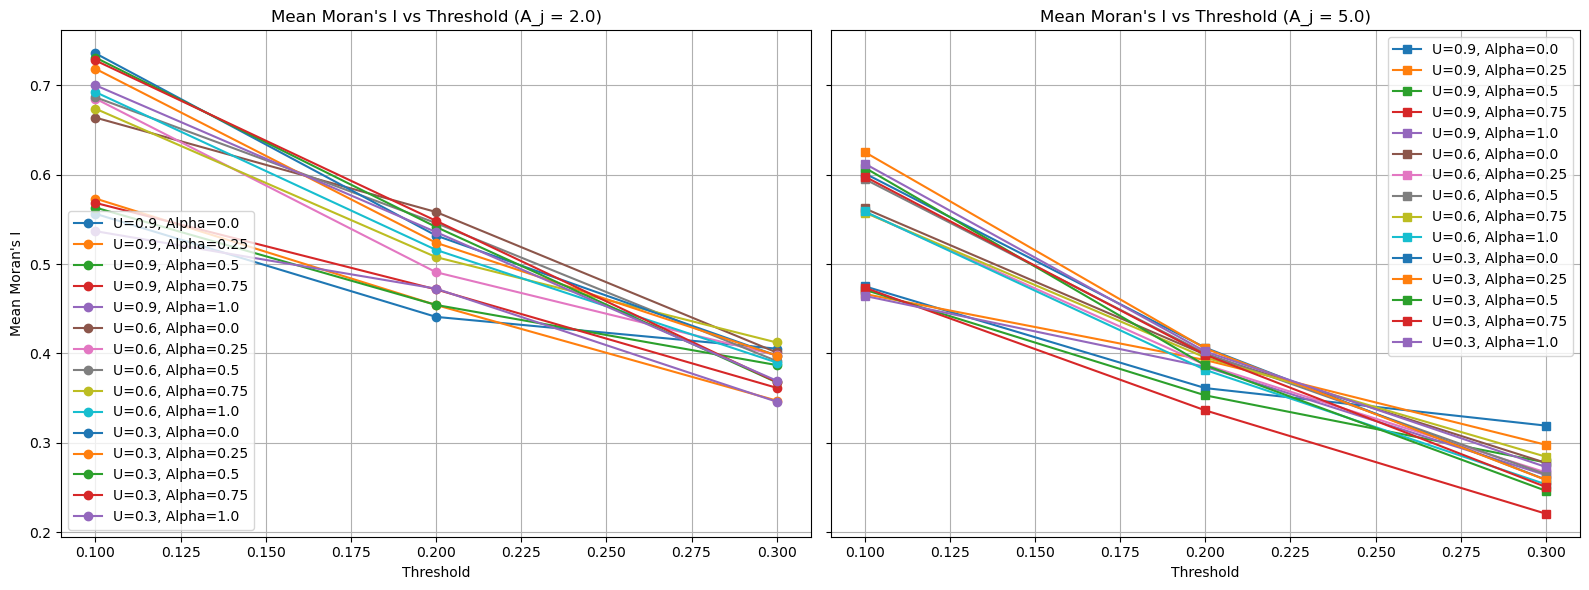

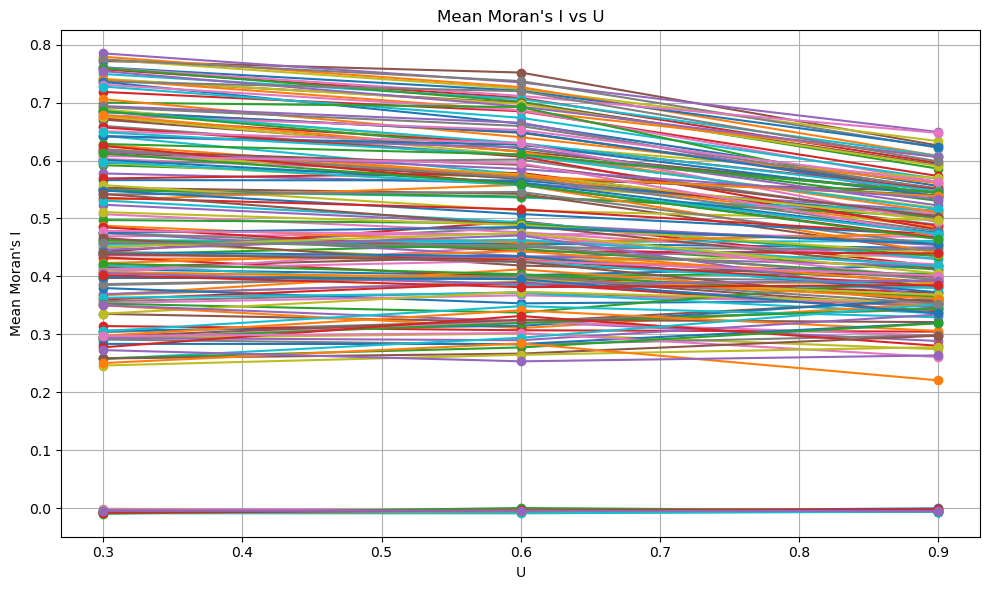

In [71]:
# Plot mean Moran's I against threshold for each combination of U and alpha, separately for A_j = 2.0 and A_j = 5.0
data = pd.read_csv("bootstrap_morans_I_results.csv")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subset for A_j = 2.0
subset_A2 = data[data['A_j'] == 2.0]
for (U, alpha) in subset_A2[['U', 'alpha']].drop_duplicates().itertuples(index=False):
    subset = subset_A2[(subset_A2['U'] == U) & (subset_A2['alpha'] == alpha)]
    axes[0].plot(subset['threshold'], subset['mean_I'], marker='o', label=f'U={U}, Alpha={alpha}')

axes[0].set_title("Mean Moran's I vs Threshold (A_j = 2.0)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Mean Moran's I")
axes[0].legend()
axes[0].grid(True)

# Subset for A_j = 5.0
subset_A5 = data[data['A_j'] == 5.0]
for (U, alpha) in subset_A5[['U', 'alpha']].drop_duplicates().itertuples(index=False):
    subset = subset_A5[(subset_A5['U'] == U) & (subset_A5['alpha'] == alpha)]
    axes[1].plot(subset['threshold'], subset['mean_I'], marker='s', label=f'U={U}, Alpha={alpha}')

axes[1].set_title("Mean Moran's I vs Threshold (A_j = 5.0)")
axes[1].set_xlabel("Threshold")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot mean Moran's I against U for each combination of A_j, threshold, and alpha
fig, ax = plt.subplots(figsize=(10, 6))

for (A_j, threshold, alpha) in data[['A_j', 'threshold', 'alpha']].drop_duplicates().itertuples(index=False):
    subset = data[(data['A_j'] == A_j) & (data['threshold'] == threshold) & (data['alpha'] == alpha)]
    ax.plot(subset['U'], subset['mean_I'], marker='o', label=f'A_j={A_j}, Threshold={threshold}, Alpha={alpha}')

ax.set_title("Mean Moran's I vs U")
ax.set_xlabel("U")
ax.set_ylabel("Mean Moran's I")
ax.grid(True)

plt.tight_layout()
plt.show()


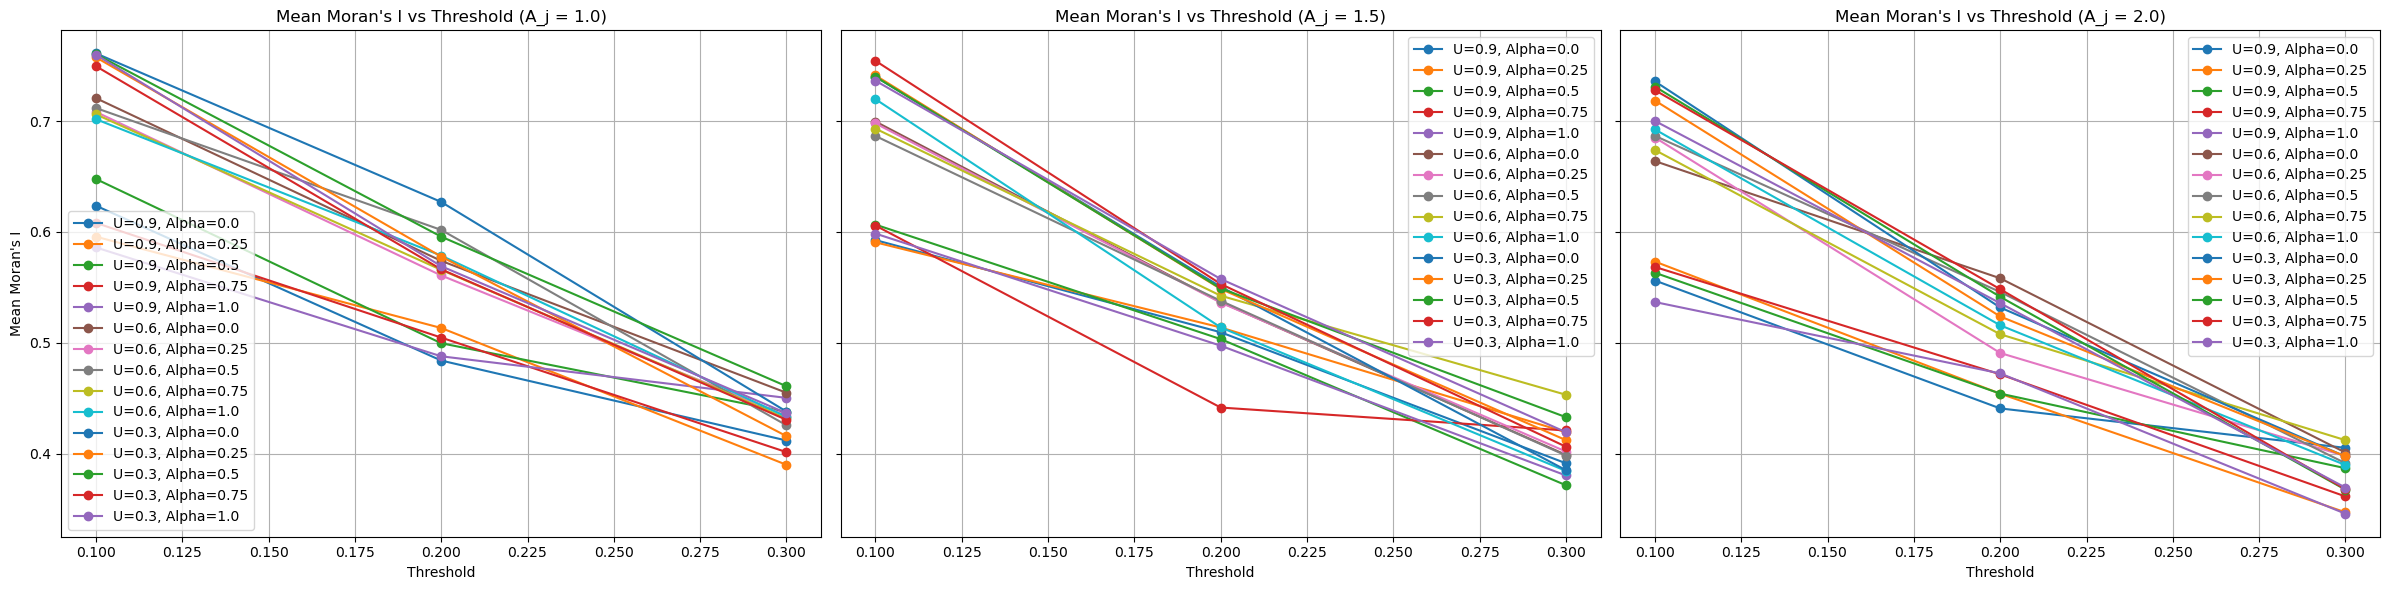

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mean_morans_I_vs_threshold(data, A_j_values):
    """
    Plots mean Moran's I against threshold for each combination of U and alpha, 
    separately for each A_j value provided.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data with columns 'A_j', 'U', 'alpha', 'threshold', and 'mean_I'.
        A_j_values (list): List of A_j values to plot separately.
    """
    num_plots = len(A_j_values)
    fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 6), sharey=True)
    
    if num_plots == 1:
        axes = [axes]  # Ensure axes is iterable if there's only one plot.

    for i, A_j in enumerate(A_j_values):
        subset_Aj = data[data['A_j'] == A_j]
        for (U, alpha) in subset_Aj[['U', 'alpha']].drop_duplicates().itertuples(index=False):
            subset = subset_Aj[(subset_Aj['U'] == U) & (subset_Aj['alpha'] == alpha)]
            axes[i].plot(subset['threshold'], subset['mean_I'], marker='o', label=f'U={U}, Alpha={alpha}')

        axes[i].set_title(f"Mean Moran's I vs Threshold (A_j = {A_j})")
        axes[i].set_xlabel("Threshold")
        if i == 0:
            axes[i].set_ylabel("Mean Moran's I")
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def plot_mean_morans_I_vs_U(data):
    """
    Plots mean Moran's I against U for each combination of A_j, threshold, and alpha.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data with columns 'A_j', 'U', 'alpha', 'threshold', and 'mean_I'.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for (A_j, threshold, alpha) in data[['A_j', 'threshold', 'alpha']].drop_duplicates().itertuples(index=False):
        subset = data[(data['A_j'] == A_j) & (data['threshold'] == threshold) & (data['alpha'] == alpha)]
        ax.plot(subset['U'], subset['mean_I'], marker='o', label=f'A_j={A_j}, Threshold={threshold}, Alpha={alpha}')

    ax.set_title("Mean Moran's I vs U")
    ax.set_xlabel("U")
    ax.set_ylabel("Mean Moran's I")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
data = pd.read_csv("bootstrap_morans_I_results.csv")
A_j_values = [1.0, 1.5, 2.0]  # Replace with your actual A_j values.

# Plot mean Moran's I vs threshold for specific A_j values
plot_mean_morans_I_vs_threshold(data, A_j_values)

# Plot mean Moran's I vs U
# plot_mean_morans_I_vs_U(data)

In [83]:
def plot_mean_morans_I_vs_threshold(data, A_j_values):
    """
    Plots mean Moran's I against threshold for each combination of U and alpha, 
    separately for each A_j value provided.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data with columns 'A_j', 'U', 'alpha', 'threshold', and 'mean_I'.
        A_j_values (list): List of A_j values to plot separately.
    """
    num_plots = len(A_j_values)
    fig, axes = plt.subplots(1, num_plots, figsize=(8 * num_plots, 6), sharey=True)
    
    if num_plots == 1:
        axes = [axes]  # Ensure axes is iterable if there's only one plot.

    for i, A_j in enumerate(A_j_values):
        subset_Aj = data[data['A_j'] == A_j]
        for (U, alpha) in subset_Aj[['U', 'alpha']].drop_duplicates().itertuples(index=False):
            subset = subset_Aj[(subset_Aj['U'] == U) & (subset_Aj['alpha'] == alpha)]
            axes[i].plot(subset['threshold'], subset['mean_I'], marker='o', label=f'U={U}, Alpha={alpha}')

        axes[i].set_title(f"Mean Moran's I vs Threshold (A_j = {A_j})")
        axes[i].set_xlabel("Threshold")
        if i == 0:
            axes[i].set_ylabel("Mean Moran's I")
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def plot_mean_morans_I_vs_U(data):
    """
    Plots mean Moran's I against U for each combination of A_j, threshold, and alpha.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data with columns 'A_j', 'U', 'alpha', 'threshold', and 'mean_I'.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for (A_j, threshold, alpha) in data[['A_j', 'threshold', 'alpha']].drop_duplicates().itertuples(index=False):
        subset = data[(data['A_j'] == A_j) & (data['threshold'] == threshold) & (data['alpha'] == alpha)]
        ax.plot(subset['U'], subset['mean_I'], marker='o', label=f'A_j={A_j}, Threshold={threshold}, Alpha={alpha}')

    ax.set_title("Mean Moran's I vs U")
    ax.set_xlabel("U")
    ax.set_ylabel("Mean Moran's I")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

def plot_mean_morans_I_with_subplots(data, A_j_values, alpha_values):
    """
    Creates subplots of Mean Moran's I vs Threshold with A_j and alpha held constant.
    Each row represents a different A_j value, and each column represents a different alpha value.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data with columns 'A_j', 'U', 'alpha', 'threshold', and 'mean_I'.
        A_j_values (list): List of A_j values to iterate over for rows.
        alpha_values (list): List of alpha values to iterate over for columns.
    """
    num_rows = len(A_j_values)
    num_cols = len(alpha_values)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), sharey=True)

    if num_rows == 1:
        axes = [axes]  # Ensure axes is iterable if there's only one row.
    if num_cols == 1:
        axes = [[ax] for ax in axes]  # Ensure 2D iterable if there's only one column.

    for i, A_j in enumerate(A_j_values):
        for j, alpha in enumerate(alpha_values):
            ax = axes[i][j]
            subset = data[(data['A_j'] == A_j) & (data['alpha'] == alpha)]
            for U in subset['U'].unique():
                subset_U = subset[subset['U'] == U]
                ax.plot(subset_U['threshold'], subset_U['mean_I'], marker='o', label=f'U={U}')

            ax.set_title(f"A_j={A_j}, Alpha={alpha}")
            ax.set_xlabel("Threshold")
            if j == 0:
                ax.set_ylabel("Mean Moran's I")
            ax.legend()
            ax.grid(True)

    plt.tight_layout()
    plt.show()

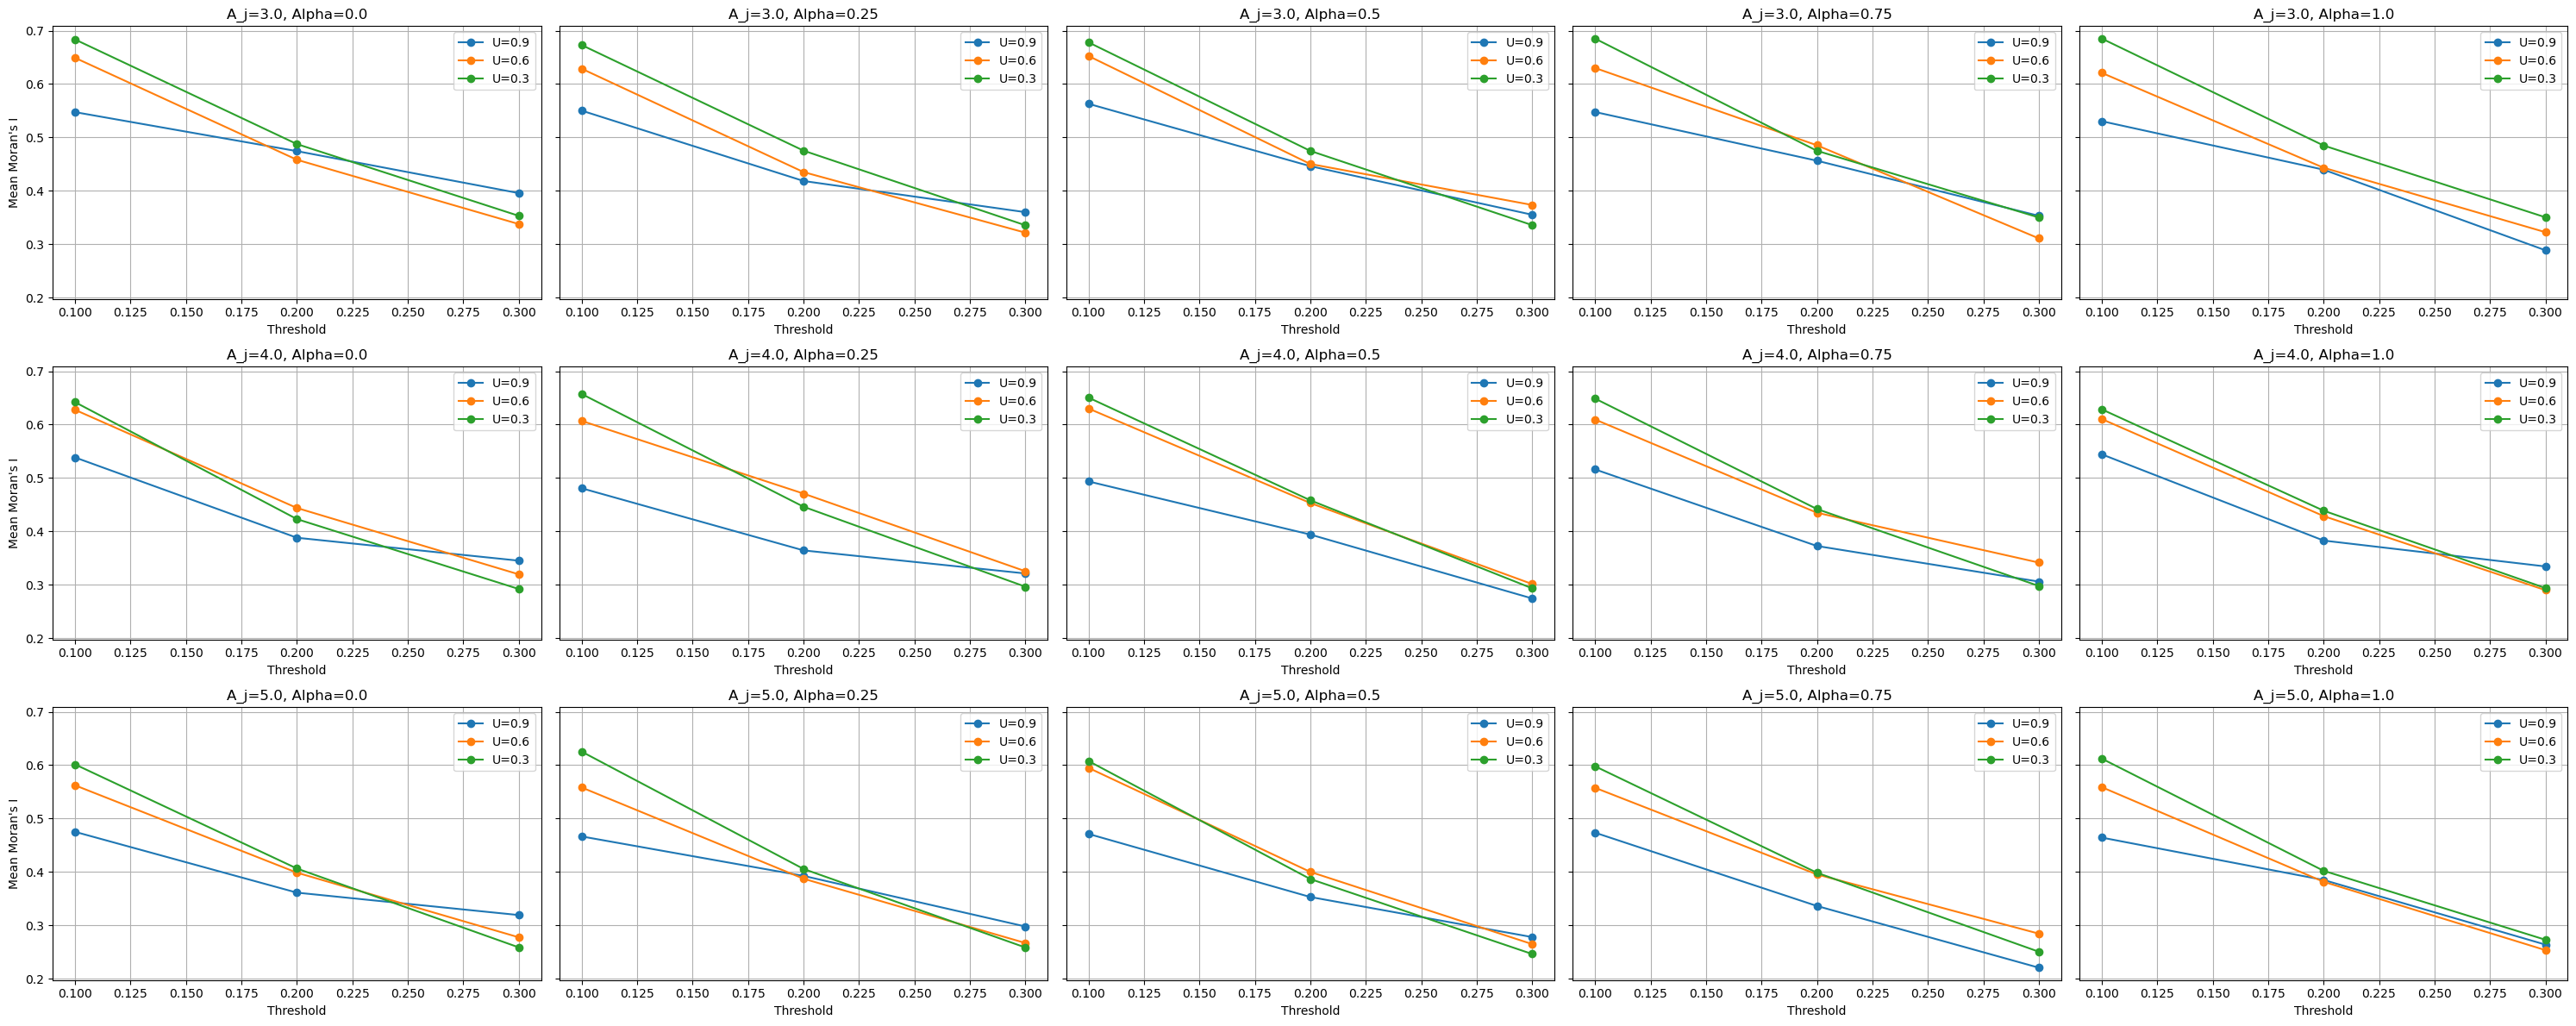

In [87]:
plot_mean_morans_I_with_subplots(data, [3.0, 4.0, 5.0], [0.0, 0.25, 0.5, 0.75, 1.0])